In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

In [ ]:
img = cv2.imread('MAILBOX.png')

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(gray, 25, 255, cv2.THRESH_BINARY_INV)
coords = cv2.findNonZero(mask)

In [ ]:
x, y, w, h = cv2.boundingRect(coords)
roi = img[y:y+h, x:x+w]

In [ ]:
yuv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2YUV)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
yuv_roi[:, :, 0] = clahe.apply(yuv_roi[:, :, 0])

In [ ]:
enhanced_roi = cv2.cvtColor(yuv_roi, cv2.COLOR_YUV2BGR)
final_img = img.copy()
final_img[y:y+h, x:x+w] = enhanced_roi

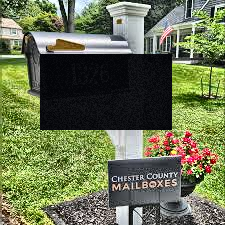

True

In [ ]:
cv2_imshow(final_img)
cv2.imwrite('mailbox_revealed.png', final_img)